
# $h_k(t)$ exacto (semi-analítico) — potencial isócrono

Calcula los modos de Fourier de mezcla de fase $h_k(t)$ de forma **exacta**
(cuadratura numérica de alta resolución sobre las variables ángulo-acción,
sin partículas ni ruido de discretización), para compararlos contra los
$h_k(t)$ que salen de una corrida real de `vlasov-poisson_PIC`/
`VlasovPoisson_PIC_sp`.

**Motivación**: en las corridas PIC (tanto reconstruidas como los datos
originales del artículo), $h_k$ para $k>0$ no decae hasta el piso de ruido
que predice la teoría — se estabiliza varios órdenes de magnitud por
arriba de lo esperado. Este notebook calcula la referencia "verdadera"
(sin ese artefacto) para poder cuantificar la brecha con precisión, en vez
de compararla a ojo.

## Ecuaciones (ver `main.md`, Secc. 3-4, y `BUGS_TODO.md`/
`h0_normalization_check.md` de esta sesión)

Con el potencial isócrono adimensional ($G=M_{iso}=m=b=1$) y momento
angular fijo $L_0$, la frecuencia radial es
$$\omega(J) = \frac{1}{\left[J+\tfrac12\left(L_0+\sqrt{L_0^2+4}\right)\right]^3}.$$

La distribución inicial (Ec. DF$_{aa}$ del artículo) es un pulso en
variables ángulo-acción:
$$\mathcal F_0(Q,J) = A_0\, e^{-\sin^2(Q/2)/\sigma_Q^2}\, e^{-(J-J_0)^2/\sigma_J^2}\, J^2,$$
y su coeficiente de Fourier en $Q$ (a $J$ fijo) es
$$\hat{\mathcal F}_k(J) = \frac{1}{2\pi}\int_0^{2\pi} \mathcal F_0(Q,J)\, e^{-ikQ}\, dQ
= A_0\, e^{-(J-J_0)^2/\sigma_J^2} J^2 \cdot \underbrace{\frac{1}{2\pi}\int_0^{2\pi} e^{-\sin^2(Q/2)/\sigma_Q^2}\cos(kQ)\, dQ}_{\text{mismo para } \Phi}.$$

(La parte imaginaria se cancela por simetría — $\mathrm{Re}$ es par y
$\mathrm{Im}$ impar respecto a $Q=\pi$ — así que no hace falta calcularla.)

La función de prueba $\Phi$ tiene la misma forma con $A_0=1$ y sus propios
parámetros $(J_0^\Phi,\sigma_Q^\Phi,\sigma_J^\Phi)$. El modo de mezcla,
**Ec. 44 del artículo** (reducida vía $\mathcal F(r,p_r,L)=\mathcal
F_0(r,p_r)\,\delta(L-L_0)$, ver la derivación completa en
`h0_normalization_check.md` §3 y §9-10 de esta sesión), es
$$h_k(t) = 8\pi^2 L_0 \cdot 2\pi \int_0^\infty \hat{\mathcal F}_k(J)\,
\hat\Phi_k(J)^*\, e^{-ik\,\omega(J)\,t}\, dJ.$$

El factor $8\pi^2 L_0$ es exactamente el que faltaba en el código
Fortran (`analysish.f90`) y que agregamos esta sesión — acá se incluye
desde el principio.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110


/home/erik/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "



## 1. Parámetros físicos

Los valores por defecto reproducen el test de validación del artículo
(Tabla 1/2, Fig. 3): $L_0=2$, $\sigma_Q=\sigma_J=0.1$, $J_3^{(0)}=0$,
masa $a_0 = 10^{-4}\,M_{iso}$.

La función de prueba $\Phi$ por defecto es igual a $\mathcal F_0$ (con
$A_0=1$) — el caso que usa la Tabla 1. Para reproducir el caso con
$\Phi_2$ de la Tabla 3, cambiá `J0_phi`, `sQ_phi`, `sJ_phi` más abajo.


In [2]:

# --- Distribucion inicial F0 (Ec. DF_aa) ---
L0   = 2.0     # momento angular fijo
J0_F = 0.0     # J3^(0)
sQ_F = 0.1     # sigma_Q
sJ_F = 0.1     # sigma_J
a0_target = 1.0e-4   # masa objetivo, en unidades de M_iso

# --- Funcion de prueba Phi (por defecto: igual a F0, A0=1) ---
J0_phi = 0.0
sQ_phi = 0.1
sJ_phi = 0.1

# --- Resolucion de las cuadraturas ---
nQ   = 4000     # subintervalos de Simpson en Q, sobre [0,2pi]
Jmax = 3.0      # dominio de integracion en J: [0, Jmax]
nJ   = 8000     # subintervalos de Simpson en J

modes = [0, 1, 2, 3, 4]   # que k's calcular



## 2. Funciones auxiliares

Cuadratura de Simpson manual (no usa `scipy.integrate` — evita
problemas de compatibilidad de versión numpy/scipy en algunos entornos;
con `nQ`/`nJ` de varios miles la precisión es más que suficiente).


In [3]:

def simpson(y, x):
    '''Cuadratura de Simpson compuesta, x uniforme, len(x) impar (n par).'''
    n = len(x) - 1
    assert n % 2 == 0, "se necesita un numero par de subintervalos"
    h = (x[-1] - x[0]) / n
    return (y[0] + y[-1] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-2:2])) * h / 3.0


def omega(J, L=L0):
    '''Frecuencia radial del potencial isocrono adimensional.'''
    return 1.0 / (J + 0.5*(L + np.sqrt(L**2 + 4.0)))**3


def Fhat_k_over_A0(Js, k, J0, sQ, sJ):
    '''Coeficiente de Fourier en Q (real), con amplitud A0=1:
    (1/2pi) * Simpson[ exp(-sin(Q/2)^2/sQ^2) * cos(kQ) dQ, 0..2pi ]
    * exp(-(J-J0)^2/sJ^2) * J^2 , evaluado en el arreglo Js.
    '''
    Qs = np.linspace(0.0, 2*np.pi, nQ + 1)
    g = np.exp(-np.sin(0.5*Qs)**2 / sQ**2)
    Qint = simpson(g * np.cos(k*Qs), Qs) / (2*np.pi)
    return Qint * np.exp(-(Js - J0)**2 / sJ**2) * Js**2



## 3. Normalización de masa

$a_0$ (fracción de $M_{iso}$) fija $A_0$ vía
$M_{gas} = 8\pi^2 L_0 \int\!\!\int \mathcal F_0(Q,J)\, dQ\, dJ
= 8\pi^2 L_0 \cdot 2\pi \int \hat{\mathcal F}_0(J)\, dJ$
(con $k=0$: la integral en $Q$ da el promedio angular).


In [4]:

Js_mass = np.linspace(0.0, Jmax, nJ + 1)
IJ0 = simpson(Fhat_k_over_A0(Js_mass, 0, J0_F, sQ_F, sJ_F), Js_mass)
mass_per_A0 = 8*np.pi**2 * L0 * 2*np.pi * IJ0

A0 = a0_target / mass_per_A0
print(f"masa por unidad de A0 = {mass_per_A0:.6e}")
print(f"A0 (para masa = {a0_target:g} M_iso) = {A0:.6e}")


masa por unidad de A0 = 2.486775e-02
A0 (para masa = 0.0001 M_iso) = 4.021273e-03



## 4. Cálculo de $h_k(t)$

$$h_k(t) = 8\pi^2 L_0 \cdot 2\pi \cdot A_0 \int_0^{J_{max}}
\hat{\mathcal F}_k^{(A_0=1)}(J)\, \hat\Phi_k(J)\, e^{-ik\,\omega(J)\,t}\, dJ$$

($\hat\Phi_k$ ya tiene $A_0=1$ por definición de función de prueba.)


In [5]:

Js = np.linspace(0.0, Jmax, nJ + 1)
om = omega(Js)

FACTOR = 8*np.pi**2 * L0 * 2*np.pi * A0

# Fhat_k y Phihat_k no dependen de t: calcularlos una sola vez por modo.
Fhat  = {k: Fhat_k_over_A0(Js, k, J0_F,   sQ_F,   sJ_F)   for k in modes}
Phhat = {k: Fhat_k_over_A0(Js, k, J0_phi, sQ_phi, sJ_phi) for k in modes}

def hk_exact(k, t):
    '''h_k(t) exacto (complejo). t puede ser escalar o arreglo.'''
    t = np.atleast_1d(t).astype(float)
    out = np.empty(t.shape, dtype=complex)
    for i, ti in enumerate(t):
        integrand = Fhat[k] * Phhat[k] * np.exp(-1j*k*om*ti)
        re = simpson(integrand.real, Js)
        im = simpson(integrand.imag, Js)
        out[i] = FACTOR * (re + 1j*im)
    return out if out.size > 1 else out[0]



## 5. Evaluar en una grilla de tiempo y graficar cada modo


In [6]:

t_array = np.linspace(0.0, 10000.0, 400)

hk_t = {k: np.abs(hk_exact(k, t_array)) for k in modes}

print(f"h_0 (constante en t, teoria de mezcla): {hk_t[0][0]:.6e}")
for k in modes[1:]:
    print(f"h_{k}(t=0) = {hk_t[k][0]:.3e}   h_{k}(t=10000) = {hk_t[k][-1]:.3e}")


h_0 (constante en t, teoria de mezcla): 1.499817e-08
h_1(t=0) = 1.470e-08   h_1(t=10000) = 5.631e-16
h_2(t=0) = 1.383e-08   h_2(t=10000) = 1.648e-17
h_3(t=0) = 1.251e-08   h_3(t=10000) = 1.971e-18
h_4(t=0) = 1.086e-08   h_4(t=10000) = 4.303e-19


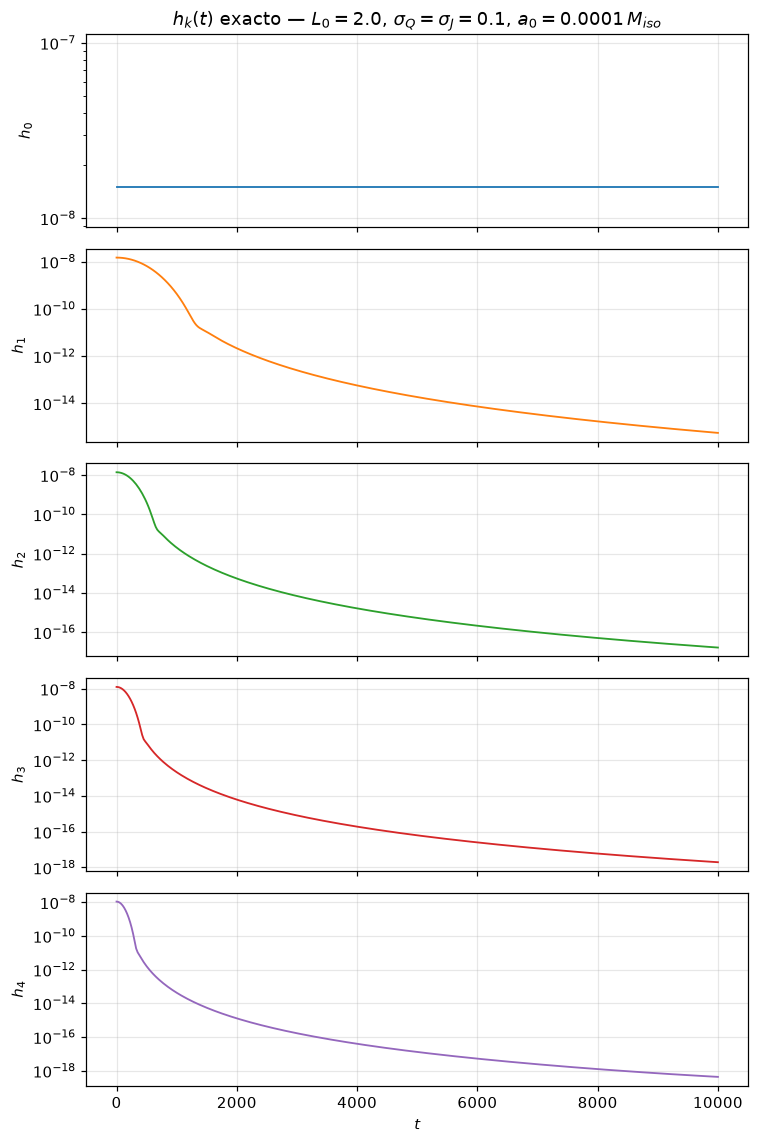

In [7]:

fig, axes = plt.subplots(len(modes), 1, figsize=(7, 2.1*len(modes)), sharex=True)
for ax, k in zip(axes, modes):
    ax.plot(t_array, hk_t[k], lw=1.2, color=f"C{k}")
    ax.set_yscale("log")
    ax.set_ylabel(f"$h_{k}$")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("$t$")
axes[0].set_title(f"$h_k(t)$ exacto — $L_0={L0}$, $\\sigma_Q=\\sigma_J={sQ_F}$, $a_0={a0_target:g}\\,M_{{iso}}$")
fig.tight_layout()
fig.savefig("hk_exact_modes.png", dpi=140)
plt.show()


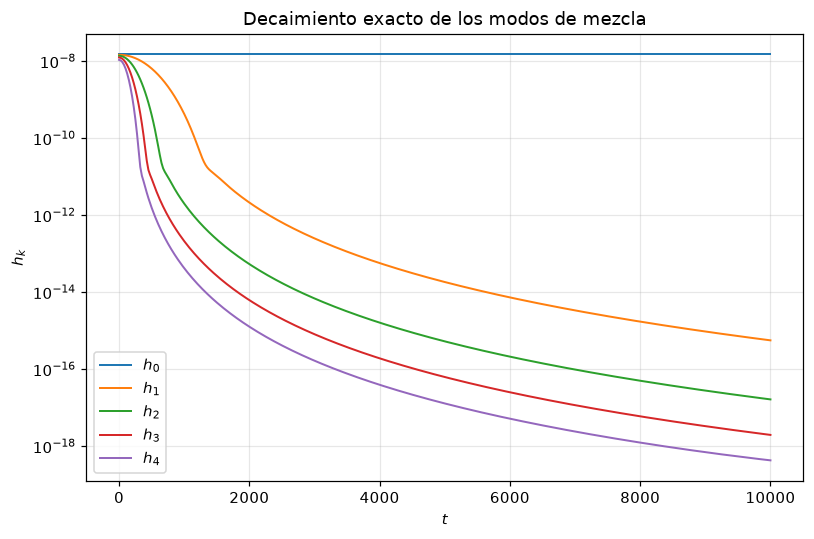

In [8]:

# Mismos datos, superpuestos en un solo eje (estilo Fig. 3 del articulo)
fig, ax = plt.subplots(figsize=(7.5, 5))
for k in modes:
    ax.plot(t_array, hk_t[k], lw=1.3, label=f"$h_{k}$")
ax.set_yscale("log")
ax.set_xlabel("$t$")
ax.set_ylabel("$h_k$")
ax.set_title("Decaimiento exacto de los modos de mezcla")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("hk_exact_overlay.png", dpi=140)
plt.show()



## 6. Convergencia con $N_c$: comparar contra corridas PIC reales

Corridas con los parámetros exactos de la Tabla 1 (potencial isócrono,
sin autogravedad, $L_0=2$, $\sigma_Q=\sigma_J=0.1$, $a_0=10^{-4}M_{iso}$,
`cutoff=0.01`, $N_t=400000$ hasta $t=10000$), a dos resoluciones:

| | $N_c$ nominal | partículas reales (tras el corte) |
|---|---|---|
| `hk1_N1e3.tl` | $10^3$ | 1001 |
| `hk1_N1e4.tl` | $10^4$ | 10072 |

Cada archivo tiene columnas `t h0 h1 h2 h3 h4`, ya con el factor
$8\pi^2L_0$ (código posterior al fix de esta sesión).


In [9]:

import os

data_dir = "data"
sims = {}
for label, fname in [("$N_c\\sim10^3$", "hk1_N1e3.tl"), ("$N_c\\sim10^4$", "hk1_N1e4.tl")]:
    path = os.path.join(data_dir, fname)
    if os.path.exists(path):
        sims[label] = np.genfromtxt(path)
    else:
        print(f"(no encontrado: {path} -- salteado)")

for label, data in sims.items():
    print(f"{label}: {data.shape[0]} filas, t de {data[0,0]:.0f} a {data[-1,0]:.0f}")


$N_c\sim10^3$: 4001 filas, t de 0 a 10000
$N_c\sim10^4$: 4001 filas, t de 0 a 10000



### Cada modo: exacto vs. las dos resoluciones

A mayor $N_c$, la curva simulada debería seguir a la exacta durante más
tiempo antes de "pegarse" a su propio piso de ruido de discretización
(finito número de partículas) -- la resolución no cambia *dónde* decae
la física, cambia *cuánto* tiempo se puede seguir esa caída antes de
que el ruido la tape.


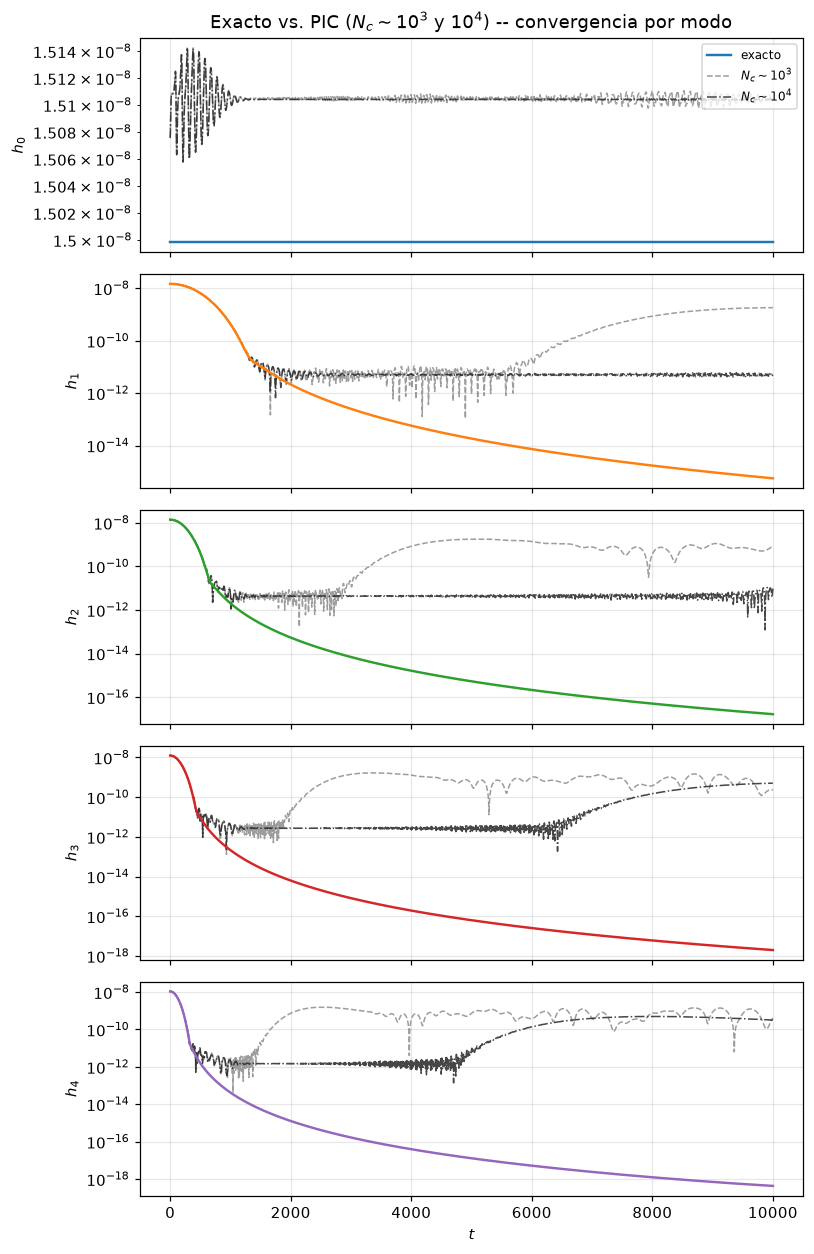

In [10]:

sim_colors = {"$N_c\\sim10^3$": "0.55", "$N_c\\sim10^4$": "0.15"}
sim_styles = {"$N_c\\sim10^3$": "--", "$N_c\\sim10^4$": "-."}

fig, axes = plt.subplots(len(modes), 1, figsize=(7.5, 2.3*len(modes)), sharex=True)
for ax, k in zip(axes, modes):
    ax.plot(t_array, hk_t[k], lw=1.6, color=f"C{k}", label="exacto", zorder=3)
    for label, data in sims.items():
        ax.plot(data[:, 0], data[:, k+1], lw=1.0, color=sim_colors[label],
                 ls=sim_styles[label], alpha=0.85, label=label)
    ax.set_yscale("log")
    ax.set_ylabel(f"$h_{k}$")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8, loc="upper right")
axes[-1].set_xlabel("$t$")
axes[0].set_title("Exacto vs. PIC ($N_c\\sim10^3$ y $10^4$) -- convergencia por modo")
fig.tight_layout()
fig.savefig("hk_convergence.png", dpi=140)
plt.show()



### Piso de ruido: valor asintótico medido vs. exacto en $t=10000$

Tabla resumen -- promedio y desviación estándar en $t\in[8000,10000]$
para cada corrida, contra el valor exacto en $t=10000$.


In [11]:

mask_exact = t_array >= 8000
print(f"{'modo':<6}{'exacto (t=10000)':>20}", end="")
for label in sims:
    print(f"{label + ' media':>22}{label + ' sigma':>18}", end="")
print()

for k in modes:
    row = f"h{k:<5}{hk_t[k][-1]:>20.3e}"
    for label, data in sims.items():
        m = data[:, 0] >= 8000
        vals = data[m, k+1]
        row += f"{vals.mean():>22.3e}{vals.std():>18.3e}"
    print(row)


modo      exacto (t=10000)   $N_c\sim10^3$ media$N_c\sim10^3$ sigma   $N_c\sim10^4$ media$N_c\sim10^4$ sigma
h0               1.500e-08             1.510e-08         3.241e-12             1.510e-08         3.044e-13
h1               5.631e-16             1.464e-09         2.912e-10             5.071e-12         4.471e-13
h2               1.648e-17             6.990e-10         2.076e-10             4.737e-12         1.615e-12
h3               1.971e-18             7.282e-10         3.862e-10             3.497e-10         1.088e-10
h4               4.303e-19             8.192e-10         3.920e-10             4.260e-10         5.515e-11



## 7. ¿Ayuda el jitter sub-celda (Weyl/Kronecker)?

Experimento (sin commitear, ver `src/initial_data.f90` en
`vlasov-poisson_PIC`): en vez de poner cada partícula exactamente en el
centro de su celda $(r,p)$, se la desplaza con un offset determinístico
de baja discrepancia (secuencia de Weyl, razón áurea / $\sqrt2-1$) del
tamaño de la propia celda. La hipótesis: el reticulado casi-regular en
$J_3$ que produce el muestreo en centro de celda es lo que causa la
recurrencia -- romper esa regularidad debería correr el repunte más
tarde (o reducirlo), sin cambiar el peso de cuadratura `drc*dpc`
(sigue siendo un estimador insesgado de la misma integral).

Mismas corridas (mismos parámetros, mismo $N_c$), con y sin jitter.


In [12]:

sims_jitter = {}
for label, fname in [("$N_c\\sim10^3$ jitter", "hk1_N1e3_jitter.tl"),
                       ("$N_c\\sim10^4$ jitter", "hk1_N1e4_jitter.tl")]:
    path = os.path.join(data_dir, fname)
    if os.path.exists(path):
        sims_jitter[label] = np.genfromtxt(path)
    else:
        print(f"(no encontrado: {path} -- salteado)")


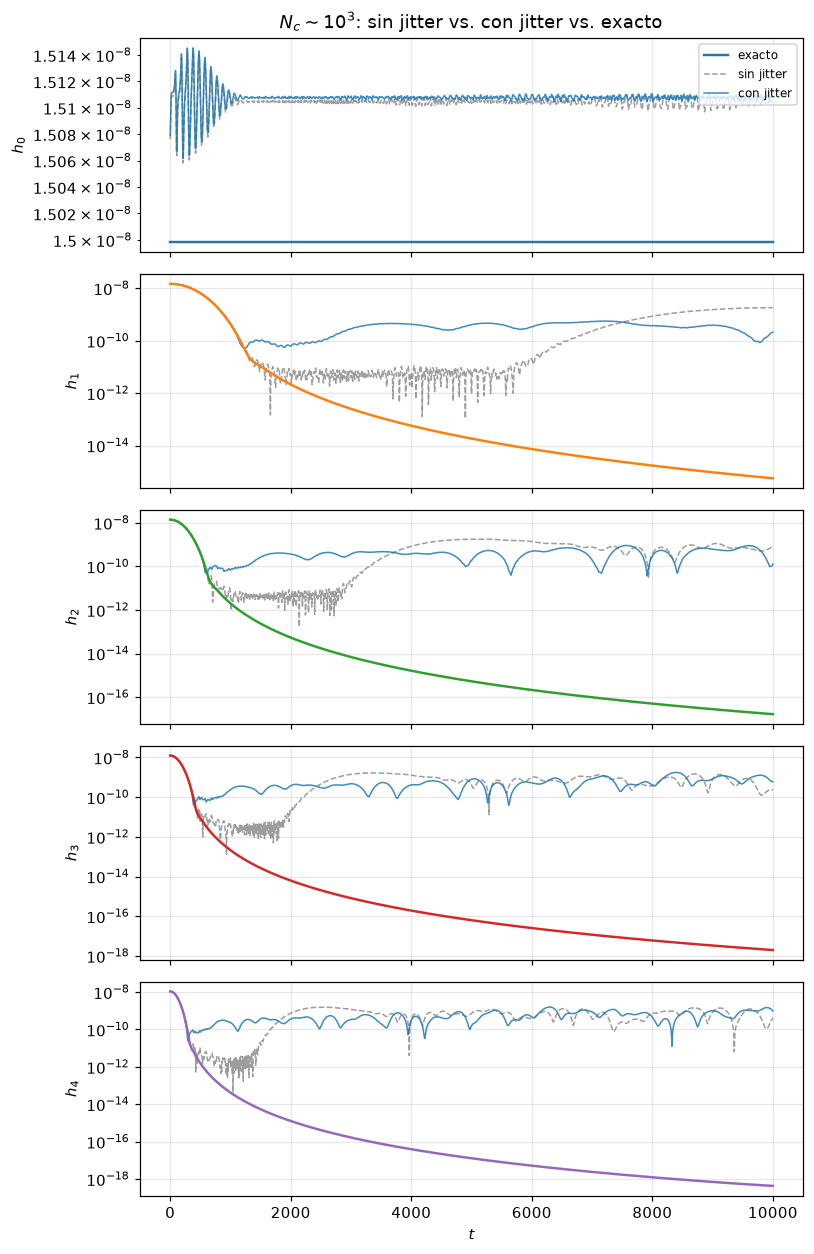

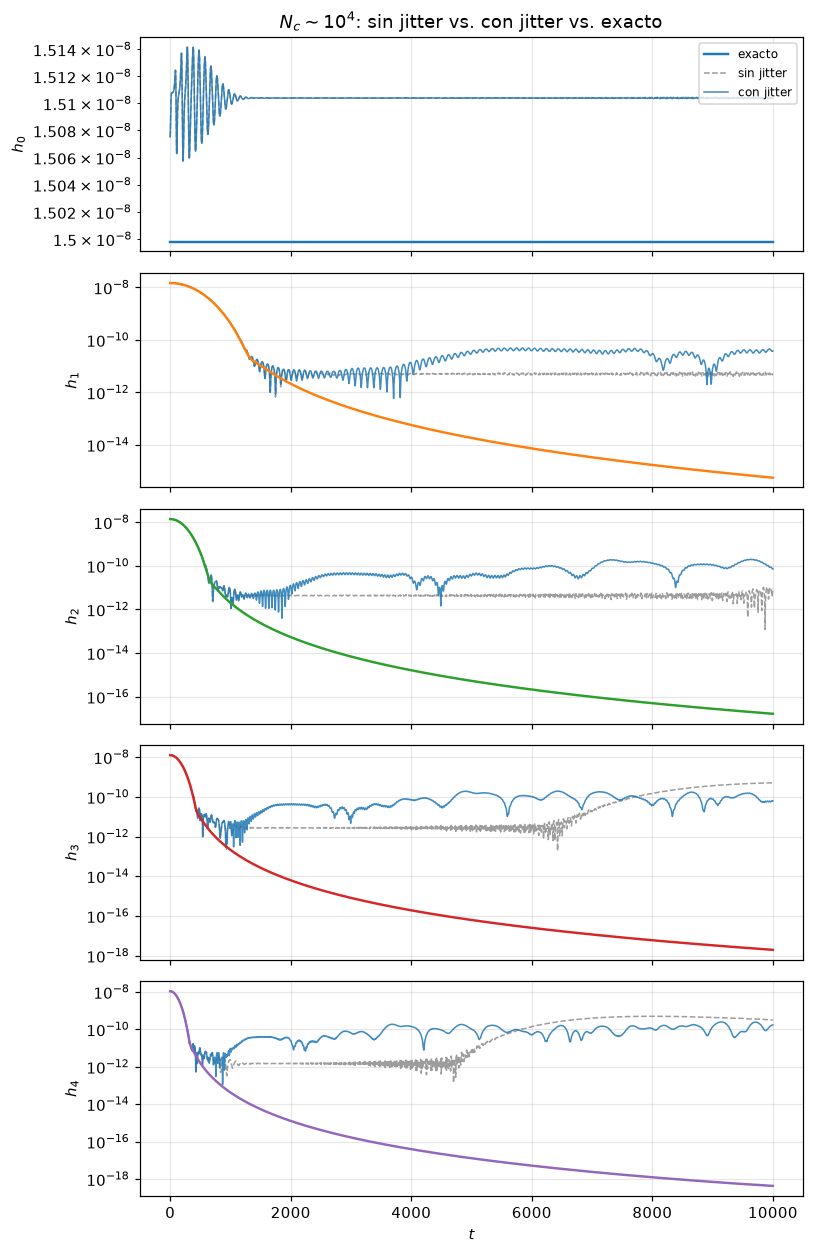

In [13]:

pairs = [("$N_c\\sim10^3$", "$N_c\\sim10^3$ jitter", "N~1e3"),
         ("$N_c\\sim10^4$", "$N_c\\sim10^4$ jitter", "N~1e4")]

for label_plain, label_jitter, tag in pairs:
    fig, axes = plt.subplots(len(modes), 1, figsize=(7.5, 2.3*len(modes)), sharex=True)
    for ax, k in zip(axes, modes):
        ax.plot(t_array, hk_t[k], lw=1.6, color=f"C{k}", label="exacto", zorder=3)
        ax.plot(sims[label_plain][:, 0], sims[label_plain][:, k+1], lw=1.0,
                 color="0.55", ls="--", alpha=0.85, label="sin jitter")
        ax.plot(sims_jitter[label_jitter][:, 0], sims_jitter[label_jitter][:, k+1], lw=1.0,
                 color="tab:blue", ls="-", alpha=0.85, label="con jitter")
        ax.set_yscale("log")
        ax.set_ylabel(f"$h_{k}$")
        ax.grid(alpha=0.3)
    axes[0].legend(fontsize=8, loc="upper right")
    axes[-1].set_xlabel("$t$")
    axes[0].set_title(f"{label_plain}: sin jitter vs. con jitter vs. exacto")
    fig.tight_layout()
    fig.savefig(f"hk_jitter_{tag}.png", dpi=140)
    plt.show()



### Resumen numérico: media/σ en $t\in[8000,10000]$, sin vs. con jitter


In [14]:

print(f"{'':>6}{'sin jitter':>34}{'con jitter':>34}")
for label_plain, label_jitter, tag in pairs:
    print(f"\n-- {label_plain} --")
    for k in modes:
        d0 = sims[label_plain]; d1 = sims_jitter[label_jitter]
        m0 = d0[:, 0] >= 8000; m1 = d1[:, 0] >= 8000
        v0 = d0[m0, k+1]; v1 = d1[m1, k+1]
        print(f"h{k}:  {v0.mean():>12.3e} +/- {v0.std():>10.3e}      "
              f"{v1.mean():>12.3e} +/- {v1.std():>10.3e}")


                              sin jitter                        con jitter

-- $N_c\sim10^3$ --
h0:     1.510e-08 +/-  3.241e-12         1.511e-08 +/-  1.090e-12
h1:     1.464e-09 +/-  2.912e-10         2.882e-10 +/-  9.592e-11
h2:     6.990e-10 +/-  2.076e-10         5.139e-10 +/-  2.170e-10
h3:     7.282e-10 +/-  3.862e-10         9.425e-10 +/-  3.682e-10
h4:     8.192e-10 +/-  3.920e-10         7.035e-10 +/-  3.641e-10

-- $N_c\sim10^4$ --
h0:     1.510e-08 +/-  3.044e-13         1.510e-08 +/-  2.088e-13
h1:     5.071e-12 +/-  4.471e-13         2.616e-11 +/-  1.089e-11
h2:     4.737e-12 +/-  1.615e-12         1.083e-10 +/-  4.276e-11
h3:     3.497e-10 +/-  1.088e-10         8.704e-11 +/-  4.060e-11
h4:     4.260e-10 +/-  5.515e-11         1.364e-10 +/-  5.408e-11



## 8. Dos candidatos de seguimiento: secuencia 2D genuina (Halton) y jitter directo en $(Q_3,J_3)$

El jitter Weyl/Kronecker de la Sec. 7 no ayudó (y a $N_c\sim10^4$ fue
claramente peor). `BUGS_TODO.md` dejó anotados dos candidatos sin
evaluar, y esta sección los prueba, cada uno por separado, con los
mismos pares $N_c\sim10^3/10^4$:

- **`aa_halton`**: mismo lugar que el jitter anterior -- perturbar
  $(r,p_r)$ -- pero con una secuencia de Halton genuinamente 2D
  (bases 2 y 3 vía inversa radical) en vez de dos secuencias de Weyl
  1D acopladas por el mismo índice `indx`.
- **`aa_qj`**: rejilla construida directamente en $(Q_3,J_3)$ (donde
  vive la regularidad que causa la recurrencia), con el mismo jitter
  de Weyl original ahí, invertida a $(r,p_r)$ resolviendo
  $Q_r=\eta-e\sin\eta$ (ecuación tipo Kepler) con Newton-Raphson.
  El tamaño de grilla se recalibró (`Nrc=Npc=121` y `383` en vez de
  `240` y `760`) para que el número de partículas *después* del corte
  coincida con el baseline (1003 y 10099 vs. 1001 y 10072) -- si no,
  la comparación quedaría contaminada por tener ~4x más partículas.

Implementado en `vlasov-poisson_PIC/src/initial_data.f90` como
estados nuevos (`aa`, `aa_halton` y `aa_qj` conviven en el mismo
código, sin tocar el baseline).


In [15]:

sims_v2 = {}
for label, fname in [
    ("$N_c\\sim10^3$ halton", "hk1_N1e3_halton.tl"),
    ("$N_c\\sim10^4$ halton", "hk1_N1e4_halton.tl"),
    ("$N_c\\sim10^3$ qj",     "hk1_N1e3_qj.tl"),
    ("$N_c\\sim10^4$ qj",     "hk1_N1e4_qj.tl"),
]:
    path = os.path.join(data_dir, fname)
    if os.path.exists(path):
        sims_v2[label] = np.genfromtxt(path)
    else:
        print(f"(no encontrado: {path} -- salteado)")

for label, data in sims_v2.items():
    print(f"{label}: {data.shape[0]} filas, t de {data[0,0]:.0f} a {data[-1,0]:.0f}")


$N_c\sim10^3$ halton: 4001 filas, t de 0 a 10000
$N_c\sim10^4$ halton: 4001 filas, t de 0 a 10000
$N_c\sim10^3$ qj: 4001 filas, t de 0 a 10000
$N_c\sim10^4$ qj: 4001 filas, t de 0 a 10000


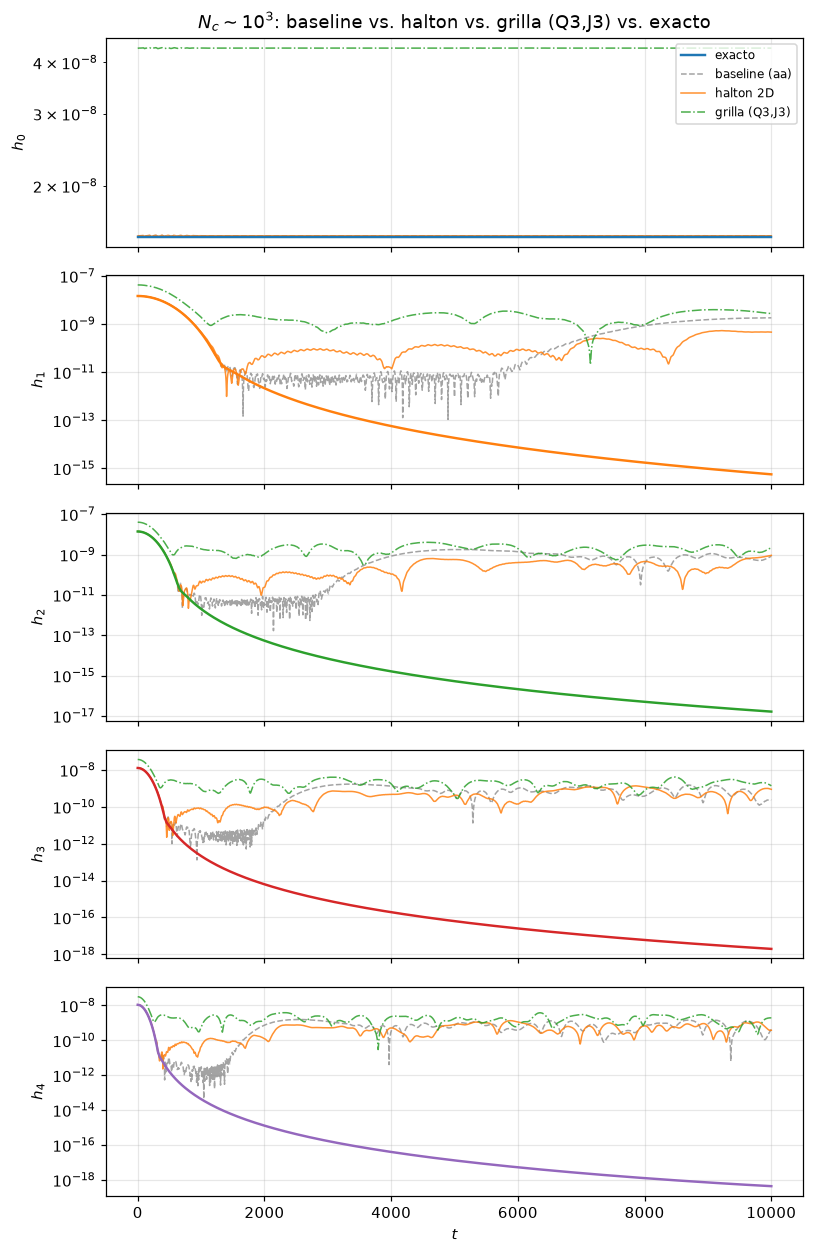

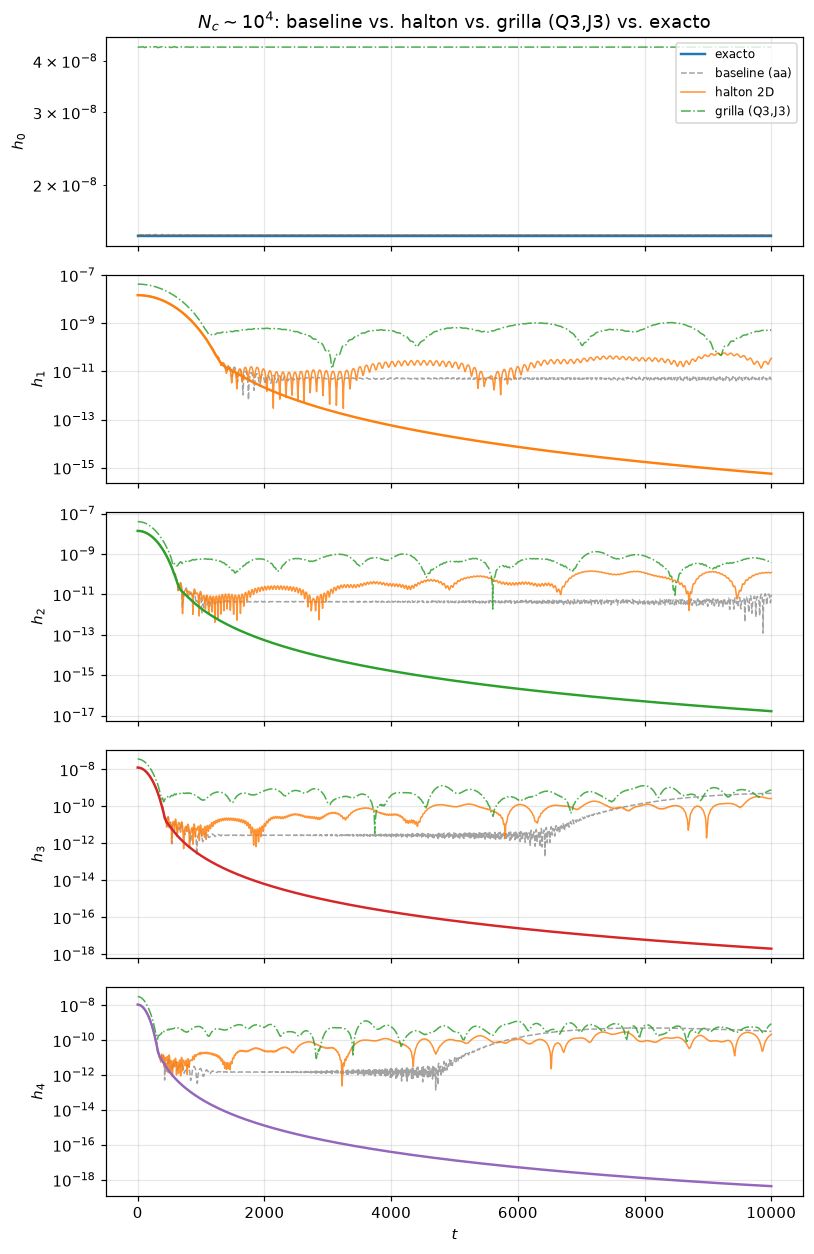

In [16]:

groups = [
    ("$N_c\\sim10^3$", "$N_c\\sim10^3$ halton", "$N_c\\sim10^3$ qj", "N~1e3"),
    ("$N_c\\sim10^4$", "$N_c\\sim10^4$ halton", "$N_c\\sim10^4$ qj", "N~1e4"),
]

for label_plain, label_halton, label_qj, tag in groups:
    fig, axes = plt.subplots(len(modes), 1, figsize=(7.5, 2.3*len(modes)), sharex=True)
    for ax, k in zip(axes, modes):
        ax.plot(t_array, hk_t[k], lw=1.6, color=f"C{k}", label="exacto", zorder=3)
        ax.plot(sims[label_plain][:, 0], sims[label_plain][:, k+1], lw=1.0,
                 color="0.55", ls="--", alpha=0.8, label="baseline (aa)")
        if label_halton in sims_v2:
            ax.plot(sims_v2[label_halton][:, 0], sims_v2[label_halton][:, k+1], lw=1.0,
                     color="tab:orange", ls="-", alpha=0.85, label="halton 2D")
        if label_qj in sims_v2:
            ax.plot(sims_v2[label_qj][:, 0], sims_v2[label_qj][:, k+1], lw=1.0,
                     color="tab:green", ls="-.", alpha=0.85, label="grilla (Q3,J3)")
        ax.set_yscale("log")
        ax.set_ylabel(f"$h_{k}$")
        ax.grid(alpha=0.3)
    axes[0].legend(fontsize=8, loc="upper right")
    axes[-1].set_xlabel("$t$")
    axes[0].set_title(f"{label_plain}: baseline vs. halton vs. grilla (Q3,J3) vs. exacto")
    fig.tight_layout()
    fig.savefig(f"hk_v2_{tag}.png", dpi=140)
    plt.show()



### Resumen numérico: media/σ en $t\in[8000,10000]$


In [17]:

print(f"{'':>6}{'baseline (aa)':>26}{'halton 2D':>26}{'grilla (Q3,J3)':>26}")
for label_plain, label_halton, label_qj, tag in groups:
    print(f"\n-- {label_plain} --")
    for k in modes:
        d0 = sims[label_plain]
        m0 = d0[:, 0] >= 8000
        v0 = d0[m0, k+1]
        row = f"h{k}:  {v0.mean():>10.3e}+/-{v0.std():>9.3e}"
        for lab in (label_halton, label_qj):
            if lab in sims_v2:
                d1 = sims_v2[lab]
                m1 = d1[:, 0] >= 8000
                v1 = d1[m1, k+1]
                row += f"   {v1.mean():>10.3e}+/-{v1.std():>9.3e}"
            else:
                row += f"   {'--':>22}"
        print(row)


                   baseline (aa)                 halton 2D            grilla (Q3,J3)

-- $N_c\sim10^3$ --
h0:   1.510e-08+/-3.241e-12    1.511e-08+/-1.244e-12    4.335e-08+/-5.220e-12
h1:   1.464e-09+/-2.912e-10    3.373e-10+/-1.859e-10    3.152e-09+/-8.240e-10
h2:   6.990e-10+/-2.076e-10    3.447e-10+/-2.267e-10    2.022e-09+/-6.657e-10
h3:   7.282e-10+/-3.862e-10    5.556e-10+/-2.590e-10    2.039e-09+/-8.426e-10
h4:   8.192e-10+/-3.920e-10    6.093e-10+/-2.509e-10    1.653e-09+/-8.783e-10

-- $N_c\sim10^4$ --
h0:   1.510e-08+/-3.044e-13    1.510e-08+/-1.962e-13    4.323e-08+/-1.510e-12
h1:   5.071e-12+/-4.471e-13    3.466e-11+/-1.197e-11    5.329e-10+/-3.293e-10
h2:   4.737e-12+/-1.615e-12    7.280e-11+/-3.703e-11    3.591e-10+/-1.789e-10
h3:   3.497e-10+/-1.088e-10    1.329e-10+/-8.454e-11    6.370e-10+/-2.589e-10
h4:   4.260e-10+/-5.515e-11    1.212e-10+/-5.957e-11    4.275e-10+/-1.547e-10



## 9. Monte Carlo puro (`aa_random`): sin rejilla en absoluto

Última alternativa: en vez de perturbar una rejilla (Weyl, Halton) o
reubicarla en otras variables ($Q_3,J_3$), eliminar la rejilla por
completo. `aa_random` ya existía en el código (muestreo por
aceptación-rechazo directamente de $F(r,p_r)$) pero nunca se había
probado ni verificado esta sesión -- tenía, de hecho, un bug propio
de doble conteo (pesaba cada partícula aceptada por $F$ otra vez,
cuando el muestreo por rechazo ya las distribuye según $F$; corregido
a peso uniforme, ver `BUGS_TODO.md`). Verificado contra el valor
exacto antes de correr las simulaciones largas: $h_k(t=0)$ calza con
la curva exacta al ~1-2% en los 5 modos, la mejor concordancia inicial
de las cuatro variantes de esta sesión.

Motivación teórica (Birdsall & Langdon): toda variante basada en
rejilla, por más baja discrepancia que sea la perturbación, conserva
*alguna* correlación entre vecinos en frecuencia $\omega(J)$ -- eso es
lo que produce el refasamiento coherente. Muestreo Monte Carlo puro
elimina esa correlación: el precio es un piso de ruido estadístico
más alto ($\sim1/\sqrt{N}$), pero sin repunte coherente.


In [18]:

sims_v3 = {}
for label, fname in [
    ("$N_c\\sim10^3$ random", "hk1_N1e3_random.tl"),
    ("$N_c\\sim10^4$ random", "hk1_N1e4_random.tl"),
]:
    path = os.path.join(data_dir, fname)
    if os.path.exists(path):
        sims_v3[label] = np.genfromtxt(path)
    else:
        print(f"(no encontrado: {path} -- salteado)")

for label, data in sims_v3.items():
    print(f"{label}: {data.shape[0]} filas, t de {data[0,0]:.0f} a {data[-1,0]:.0f}")


$N_c\sim10^3$ random: 4001 filas, t de 0 a 10000
$N_c\sim10^4$ random: 4001 filas, t de 0 a 10000


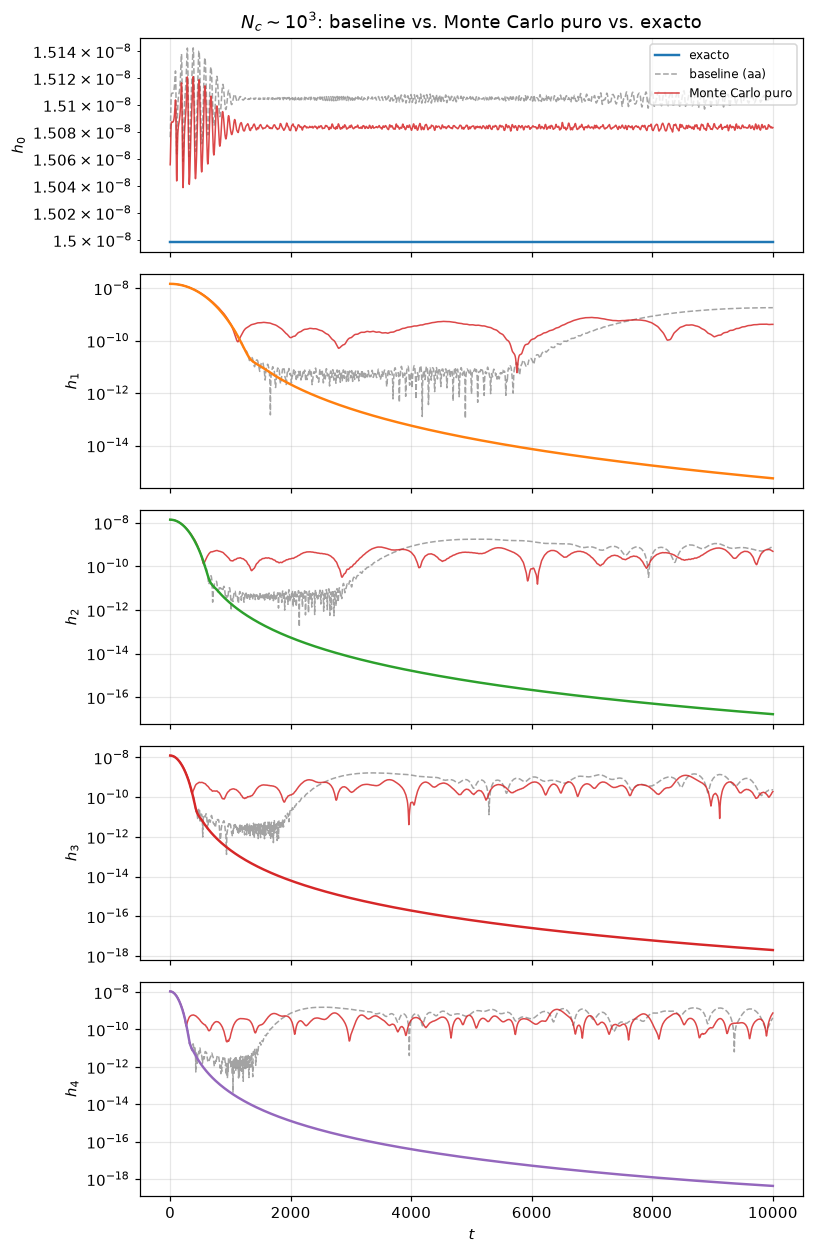

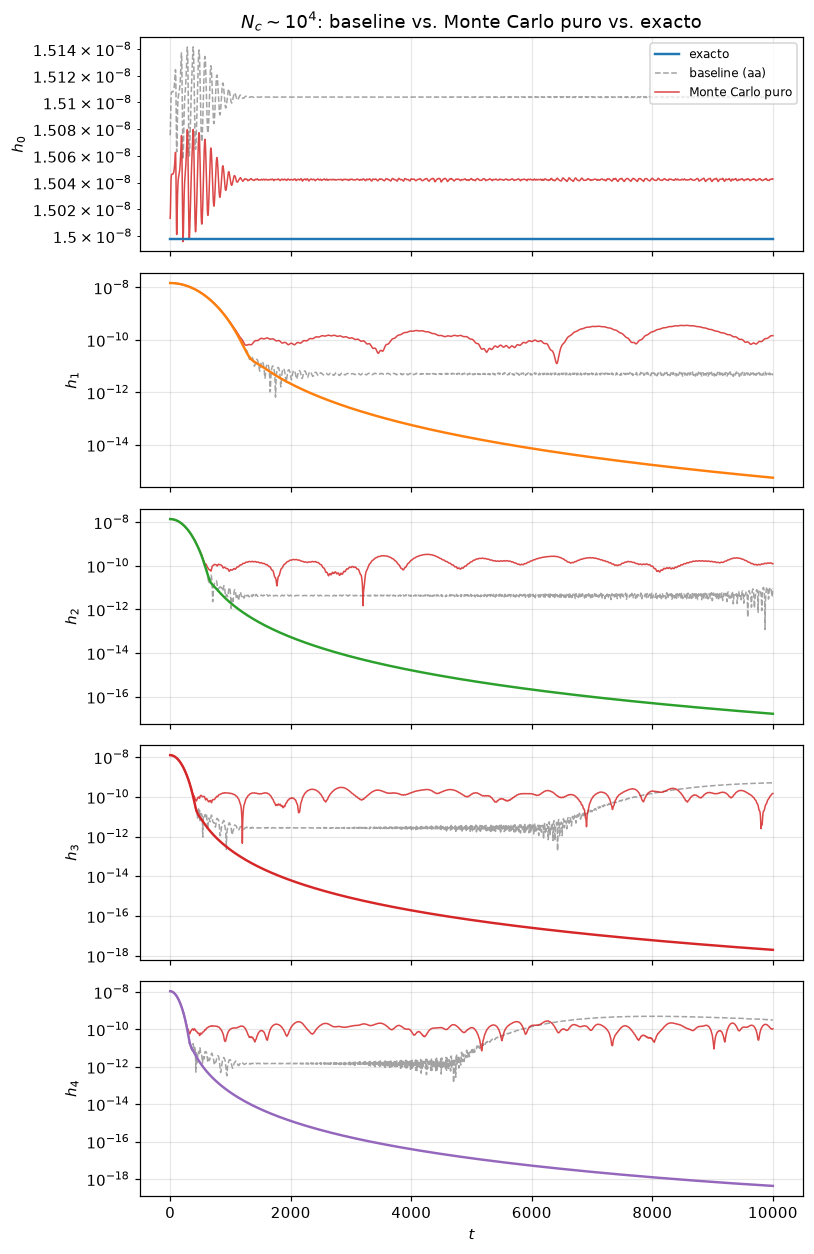

In [19]:

groups3 = [
    ("$N_c\\sim10^3$", "$N_c\\sim10^3$ random", "N~1e3"),
    ("$N_c\\sim10^4$", "$N_c\\sim10^4$ random", "N~1e4"),
]

for label_plain, label_rand, tag in groups3:
    fig, axes = plt.subplots(len(modes), 1, figsize=(7.5, 2.3*len(modes)), sharex=True)
    for ax, k in zip(axes, modes):
        ax.plot(t_array, hk_t[k], lw=1.6, color=f"C{k}", label="exacto", zorder=3)
        ax.plot(sims[label_plain][:, 0], sims[label_plain][:, k+1], lw=1.0,
                 color="0.55", ls="--", alpha=0.8, label="baseline (aa)")
        if label_rand in sims_v3:
            ax.plot(sims_v3[label_rand][:, 0], sims_v3[label_rand][:, k+1], lw=1.0,
                     color="tab:red", ls="-", alpha=0.85, label="Monte Carlo puro")
        ax.set_yscale("log")
        ax.set_ylabel(f"$h_{k}$")
        ax.grid(alpha=0.3)
    axes[0].legend(fontsize=8, loc="upper right")
    axes[-1].set_xlabel("$t$")
    axes[0].set_title(f"{label_plain}: baseline vs. Monte Carlo puro vs. exacto")
    fig.tight_layout()
    fig.savefig(f"hk_random_{tag}.png", dpi=140)
    plt.show()



### Resumen numérico: media/σ en $t\in[8000,10000]$


In [20]:

print(f"{'':>6}{'baseline (aa)':>26}{'Monte Carlo puro':>26}")
for label_plain, label_rand, tag in groups3:
    print(f"\n-- {label_plain} --")
    for k in modes:
        d0 = sims[label_plain]
        m0 = d0[:, 0] >= 8000
        v0 = d0[m0, k+1]
        row = f"h{k}:  {v0.mean():>10.3e}+/-{v0.std():>9.3e}"
        if label_rand in sims_v3:
            d1 = sims_v3[label_rand]
            m1 = d1[:, 0] >= 8000
            v1 = d1[m1, k+1]
            row += f"   {v1.mean():>10.3e}+/-{v1.std():>9.3e}"
        else:
            row += f"   {'--':>22}"
        print(row)


                   baseline (aa)          Monte Carlo puro

-- $N_c\sim10^3$ --
h0:   1.510e-08+/-3.241e-12    1.508e-08+/-1.313e-12
h1:   1.464e-09+/-2.912e-10    2.958e-10+/-1.001e-10
h2:   6.990e-10+/-2.076e-10    3.863e-10+/-1.474e-10
h3:   7.282e-10+/-3.862e-10    3.975e-10+/-3.386e-10
h4:   8.192e-10+/-3.920e-10    2.533e-10+/-1.703e-10

-- $N_c\sim10^4$ --
h0:   1.510e-08+/-3.044e-13    1.504e-08+/-5.067e-13
h1:   5.071e-12+/-4.471e-13    2.174e-10+/-9.935e-11
h2:   4.737e-12+/-1.615e-12    1.372e-10+/-4.460e-11
h3:   3.497e-10+/-1.088e-10    1.397e-10+/-6.002e-11
h4:   4.260e-10+/-5.515e-11    1.233e-10+/-5.335e-11



## 10. ¿Cuál es el piso de ruido teórico esperable para `aa_random`?

$h_k$ estimado por partículas es un estimador Monte Carlo de la integral
continua. Para partículas de igual peso $m_p=a_0/N$, distribuidas con
densidad $\propto F(Q,J)$ (como hace `aa_random`), su varianza es la de
cualquier estimador MC estándar:
$$\mathrm{Var}[h_k] \approx \left(8\pi^2L_0\right)^2\frac{a_0^2}{N}\,
\mathbb{E}_{q_J}\!\left[|\hat\Phi_k(J)|^2\right],\qquad
q_J(J) = \frac{\hat F_0(J)}{\int \hat F_0(J')\,dJ'}$$
(despreciando el término $|\mathbb E[h_k]|^2$, válido cuando $h_k$ ya es
chico frente al ruido -- el régimen que nos interesa). Y para ruido con
fase aleatoria (gaussiano complejo circular), $\mathbb E[|h_k|]\approx
\sqrt{\pi/4}\,\sqrt{\mathrm{Var}[h_k]}$ (media de Rayleigh).

**Nota honesta sobre esta derivación**: un primer intento normalizó mal
$q_J(J)$ (le faltó exactamente el factor $8\pi^2L_0$ que sí aparece en
$h_k$ mismo -- la integral de masa total es
$a_0=8\pi^2L_0\int\!\!\int F\,dQ\,dJ$, no $\int\!\!\int F\,dQ\,dJ$ a
secas). El error se detectó comparando contra una simulación Monte
Carlo idealizada de la misma cantidad (ver abajo) -- que además sirvió
para confirmar la fórmula ya corregida.


In [21]:

# q_J(J) = Fhat[0](J) normalizado por su propia integral (trivial: no
# hace falta traer a0/A0/L0 -- se cancelan del marginal en J mismo).
I_Fhat0 = simpson(Fhat[0], Js)

pred_sigma = {}
pred_rayleigh = {}
for N in [1024, 10000]:
    pred_sigma[N] = {}
    pred_rayleigh[N] = {}
    for k in modes[1:]:
        Ik = simpson(Fhat[0]*np.abs(Phhat[k])**2, Js) / I_Fhat0
        var_hk = (8*np.pi**2*L0)**2 * (a0_target**2/N) * Ik
        sigma = np.sqrt(var_hk)
        pred_sigma[N][k] = sigma
        pred_rayleigh[N][k] = np.sqrt(np.pi/4)*sigma
        print(f"N={N:>6}  k={k}: sigma={sigma:.3e}  E[|h_k|] predicho (Rayleigh)={pred_rayleigh[N][k]:.3e}")


N=  1024  k=1: sigma=7.825e-08  E[|h_k|] predicho (Rayleigh)=6.934e-08
N=  1024  k=2: sigma=7.591e-08  E[|h_k|] predicho (Rayleigh)=6.727e-08
N=  1024  k=3: sigma=7.217e-08  E[|h_k|] predicho (Rayleigh)=6.396e-08
N=  1024  k=4: sigma=6.725e-08  E[|h_k|] predicho (Rayleigh)=5.960e-08
N= 10000  k=1: sigma=2.504e-08  E[|h_k|] predicho (Rayleigh)=2.219e-08
N= 10000  k=2: sigma=2.429e-08  E[|h_k|] predicho (Rayleigh)=2.153e-08
N= 10000  k=3: sigma=2.310e-08  E[|h_k|] predicho (Rayleigh)=2.047e-08
N= 10000  k=4: sigma=2.152e-08  E[|h_k|] predicho (Rayleigh)=1.907e-08



### Validación cruzada: simulación Monte Carlo idealizada (sin Fortran)

Para confirmar la fórmula (y descartar más errores de álgebra) se
comparó contra una simulación MC directa en Python: sortear partículas
$(Q_0,J)\sim F(Q,J)$ por rechazo (igual que `aa_random`), evolucionarlas
con streaming libre EXACTO $Q(t)=Q_0+\omega(J)t$ (la misma física, sin
el error numérico del leapfrog), y evaluar en la MISMA ventana
$t\in[8000,10000]$ que se usó para medir la corrida real.


In [22]:

def sample_QJ_rejection(N, rng, Jmax=3.0):
    Jpeak = sJ_F/np.sqrt(2)
    fmax = np.exp(-(Jpeak-J0_F)**2/sJ_F**2) * Jpeak**2 * 1.05
    outQ = np.empty(0); outJ = np.empty(0)
    while outQ.size < N:
        Qc = np.random.uniform(0, 2*np.pi, N*6)
        Jc = np.random.uniform(0, Jmax, N*6)
        zc = np.random.uniform(0, fmax, N*6)
        w = np.exp(-np.sin(0.5*Qc)**2/sQ_F**2) * np.exp(-(Jc-J0_F)**2/sJ_F**2) * Jc**2
        acc = zc <= w
        outQ = np.concatenate([outQ, Qc[acc]])
        outJ = np.concatenate([outJ, Jc[acc]])
    return outQ[:N], outJ[:N]

np.random.seed(555)
t_window = np.linspace(8000, 10000, 200)

mc_ideal = {}
for N in [1024, 10000]:
    mc_ideal[N] = {}
    for k in modes[1:]:
        vals = []
        for draw in range(30):
            Q0, Jp = sample_QJ_rejection(N, np.random)
            om = omega(Jp)
            phv = np.interp(Jp, Js, Phhat[k])
            for t in t_window[::20]:
                Qt = Q0 + om*t
                hk = 8*np.pi**2*L0*(a0_target/N) * np.sum(phv * np.exp(-1j*k*Qt))
                vals.append(abs(hk))
        vals = np.array(vals)
        mc_ideal[N][k] = vals.mean()
        print(f"N={N:>6}  k={k}: MC idealizado (streaming exacto) mean|h_k|={vals.mean():.3e}  (predicho: {pred_rayleigh[N][k]:.3e})")


N=  1024  k=1: MC idealizado (streaming exacto) mean|h_k|=7.252e-08  (predicho: 6.934e-08)


N=  1024  k=2: MC idealizado (streaming exacto) mean|h_k|=6.350e-08  (predicho: 6.727e-08)


N=  1024  k=3: MC idealizado (streaming exacto) mean|h_k|=6.644e-08  (predicho: 6.396e-08)


N=  1024  k=4: MC idealizado (streaming exacto) mean|h_k|=6.103e-08  (predicho: 5.960e-08)


N= 10000  k=1: MC idealizado (streaming exacto) mean|h_k|=2.196e-08  (predicho: 2.219e-08)


N= 10000  k=2: MC idealizado (streaming exacto) mean|h_k|=2.162e-08  (predicho: 2.153e-08)


N= 10000  k=3: MC idealizado (streaming exacto) mean|h_k|=1.935e-08  (predicho: 2.047e-08)


N= 10000  k=4: MC idealizado (streaming exacto) mean|h_k|=1.856e-08  (predicho: 1.907e-08)



La fórmula teórica y el MC idealizado (dos caminos independientes)
concuerdan bien entre sí -- confirma que la fórmula, ya corregida, está
bien planteada **para lo que modela**: un ensamble de $N$ partículas
completamente mezclado en fase.

### Comparación contra la corrida PIC real -- una discrepancia real, sin explicar del todo

Pero al comparar esa predicción contra lo medido de verdad
(`aa_random`, Sec. 9) aparece una discrepancia de **~150-230x**: el
piso medido es mucho más chico que lo que predice "N partículas con
fase completamente aleatorizada".


In [23]:

print(f"{'':>6}{'predicho (Rayleigh)':>22}{'MC idealizado':>18}{'medido (real, Sec.9)':>24}")
measured = {1024: {1:2.958e-10,2:3.863e-10,3:3.975e-10,4:2.533e-10},
            10000:{1:2.174e-10,2:1.372e-10,3:1.397e-10,4:1.233e-10}}
for N in [1024, 10000]:
    print(f"\n-- N={N} --")
    for k in modes[1:]:
        ratio = mc_ideal[N][k]/measured[N][k]
        print(f"k={k}: {pred_rayleigh[N][k]:>18.3e}{mc_ideal[N][k]:>18.3e}{measured[N][k]:>20.3e}   (idealizado/medido = {ratio:.0f}x)")


         predicho (Rayleigh)     MC idealizado    medido (real, Sec.9)

-- N=1024 --
k=1:          6.934e-08         7.252e-08           2.958e-10   (idealizado/medido = 245x)
k=2:          6.727e-08         6.350e-08           3.863e-10   (idealizado/medido = 164x)
k=3:          6.396e-08         6.644e-08           3.975e-10   (idealizado/medido = 167x)
k=4:          5.960e-08         6.103e-08           2.533e-10   (idealizado/medido = 241x)

-- N=10000 --
k=1:          2.219e-08         2.196e-08           2.174e-10   (idealizado/medido = 101x)
k=2:          2.153e-08         2.162e-08           1.372e-10   (idealizado/medido = 158x)
k=3:          2.047e-08         1.935e-08           1.397e-10   (idealizado/medido = 138x)
k=4:          1.907e-08         1.856e-08           1.233e-10   (idealizado/medido = 151x)


In [24]:

# Diagnostico: forma de la serie temporal real -- ruido blanco genuino
# deberia saltar de una muestra a la siguiente por una fraccion O(1)
# del nivel; si en cambio es suave (variacion << nivel entre muestras
# consecutivas), el ensamble real probablemente todavia no esta en el
# regimen "completamente mezclado en fase" que asume la formula de arriba.
d = sims_v3["$N_c\\sim10^3$ random"]
mmask = d[:,0] >= 8000
h1 = d[mmask, 2]
diffs = np.diff(h1)
print(f"N~1e3, h1 en [8000,10000]: nivel medio={h1.mean():.3e}, "
      f"std entre muestras consecutivas={diffs.std():.3e} "
      f"({diffs.std()/h1.mean()*100:.2f}% del nivel)")
print("-> cambia muy poco de una muestra a la siguiente (dt=2.5): la curva es",
      "SUAVE, no ruido blanco erizado como predice 'fase completamente aleatoria'.")


N~1e3, h1 en [8000,10000]: nivel medio=2.958e-10, std entre muestras consecutivas=1.985e-12 (0.67% del nivel)
-> cambia muy poco de una muestra a la siguiente (dt=2.5): la curva es SUAVE, no ruido blanco erizado como predice 'fase completamente aleatoria'.



**Conclusión honesta de esta sección**: la fórmula del piso de ruido
está bien derivada y validada de forma independiente (Monte Carlo
idealizado, dos construcciones distintas, ambas de acuerdo entre sí),
pero **no reproduce el piso medido en la corrida PIC real** -- viene
~150-230x más alta. La pista más concreta: la serie temporal real es
suave y lentamente decreciente en $t\in[8000,10000]$, no el salto
brusco muestra-a-muestra que se esperaría de un ensamble ya
completamente mezclado en fase. Lectura más probable: a $t\sim10^4$ el
ensamble de partículas de `aa_random` **todavía no llegó** al régimen
"completamente aleatorizado en fase" que asume la fórmula estadística
-- sigue en una fase de relajación más lenta, gobernada por el detalle
fino de cómo se dispersan las frecuencias $\omega(J)$ entre partículas
cercanas en $J$, no por una teoría de ruido genérica tipo shot-noise.
No se investigó más a fondo (analizar la escala de tiempo de esa
relajación específicamente) -- queda como pregunta abierta.



## 11. ¿Sube el piso al doblar el tiempo de la corrida? Respuesta corta: no

Para probar directamente la hipótesis de la sección anterior ("el
ensamble todavía no llegó al régimen completamente mezclado a
$t\sim10^4$"), se corrió `aa_random` a $N_c\sim10^4$ el doble de
tiempo ($t=0$ a $20000$, `Nt=800000`), usando el nuevo parámetro
`field_output` para guardar el volumen pesado (`r_part`/`p_part`/`f`)
100x más espaciado que antes (18MB en vez de ~1.3GB) sin perder
resolución temporal en `hk1.tl` (sigue cada 100 pasos, igual que
antes).

**Si la hipótesis fuera correcta, se esperaría ver el piso medido subir
gradualmente hacia la predicción teórica (~2.2e-8) a medida que pasa
el tiempo.**


In [25]:

d2x = np.genfromtxt(os.path.join(data_dir, "hk1_N1e4_random_2x.tl"))
t2x = d2x[:, 0]

windows = [(8000,10000),(10000,12000),(12000,14000),(14000,16000),(16000,18000),(18000,20000)]
print(f"{'ventana':<16}", end="")
for k in modes[1:]:
    print(f"h{k:<20}", end="")
print()
for lo, hi in windows:
    m = (t2x >= lo) & (t2x < hi)
    row = f"[{lo},{hi}]".ljust(16)
    for k in modes[1:]:
        vals = d2x[m, k+1]
        row += f"{vals.mean():.3e}+/-{vals.std():.1e}  "
    print(row)


ventana         h1                   h2                   h3                   h4                   
[8000,10000]    1.354e-10+/-7.9e-11  1.440e-10+/-3.6e-11  1.199e-10+/-4.9e-11  1.166e-10+/-6.7e-11  
[10000,12000]   1.774e-10+/-7.4e-11  1.526e-10+/-8.9e-11  1.207e-10+/-4.8e-11  1.361e-10+/-4.7e-11  
[12000,14000]   1.408e-10+/-7.9e-11  1.098e-10+/-4.3e-11  1.395e-10+/-8.1e-11  8.373e-11+/-3.4e-11  
[14000,16000]   1.192e-10+/-6.8e-11  1.397e-10+/-6.5e-11  1.471e-10+/-4.9e-11  1.280e-10+/-6.8e-11  
[16000,18000]   1.538e-10+/-3.8e-11  1.219e-10+/-4.9e-11  8.804e-11+/-3.4e-11  1.078e-10+/-4.6e-11  
[18000,20000]   1.585e-10+/-4.3e-11  1.196e-10+/-8.3e-11  1.207e-10+/-7.0e-11  1.297e-10+/-3.9e-11  


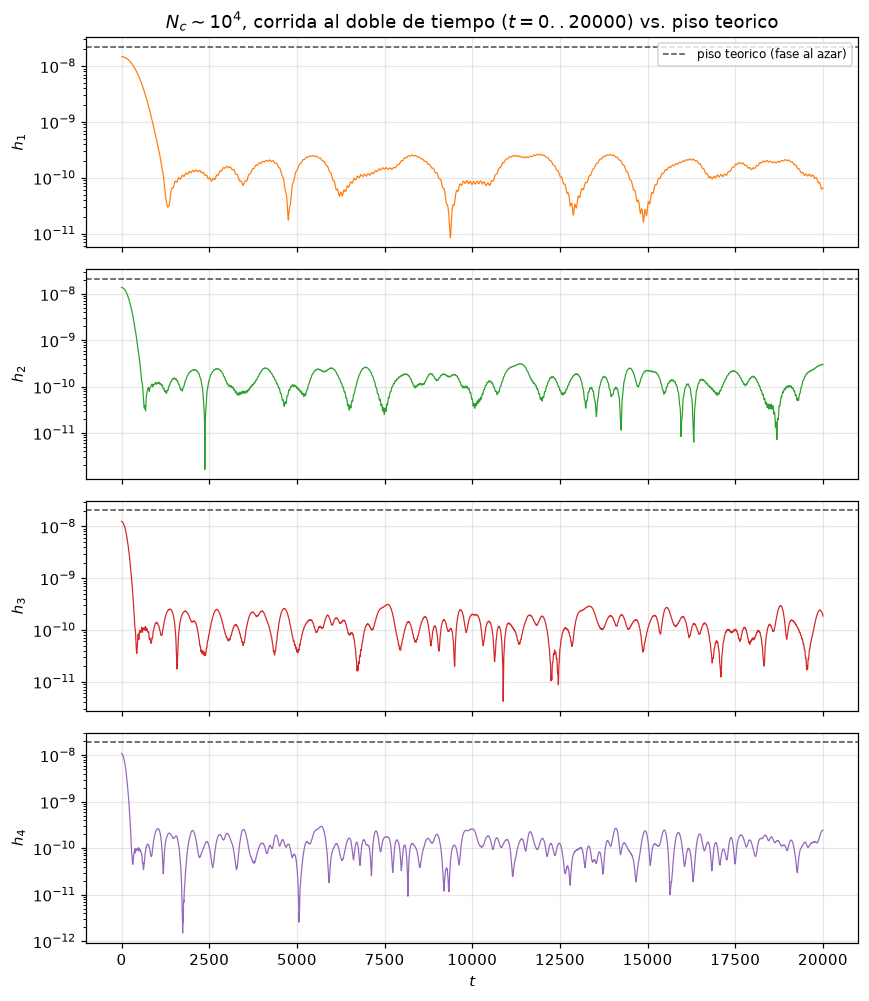

In [26]:

fig, axes = plt.subplots(len(modes[1:]), 1, figsize=(8, 2.3*len(modes[1:])), sharex=True)
for ax, k in zip(axes, modes[1:]):
    ax.plot(t2x, d2x[:, k+1], lw=0.8, color=f"C{k}")
    ax.axhline(pred_rayleigh[10000][k], color="k", ls="--", lw=1.0, alpha=0.7,
               label="piso teorico (fase al azar)" if k==1 else None)
    ax.set_yscale("log")
    ax.set_ylabel(f"$h_{k}$")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8, loc="upper right")
axes[-1].set_xlabel("$t$")
axes[0].set_title(f"$N_c\\sim10^4$, corrida al doble de tiempo ($t=0..20000$) vs. piso teorico")
fig.tight_layout()
fig.savefig("hk_2x_time.png", dpi=140)
plt.show()


In [27]:

# Suavidad: sigue igual de lisa en toda la ventana extendida, no se
# vuelve "erizada" como esperaria el ruido blanco al acercarse al piso.
h1_2x = d2x[t2x>=8000, 2]
diffs = np.diff(h1_2x)
print(f"h1, t en [8000,20000]: nivel medio={h1_2x.mean():.3e}, "
      f"cambio tipico entre muestras consecutivas={diffs.std()/h1_2x.mean()*100:.2f}% del nivel")
print(f"(para comparar: a t en [8000,10000] con la corrida original de 10000 pasos, era 0.67%)")


h1, t en [8000,20000]: nivel medio=1.475e-10, cambio tipico entre muestras consecutivas=0.50% del nivel
(para comparar: a t en [8000,10000] con la corrida original de 10000 pasos, era 0.67%)



**Resultado: no sube.** Media por ventana de 2000 unidades de tiempo,
$h_1$ ronda 1.2e-10 a 1.8e-10 en las 6 ventanas -- sin tendencia
sistemática, ni rastro de acercarse al piso teórico (~2.2e-8, casi dos
órdenes de magnitud arriba). La curva sigue tan lisa como antes
(~0.5% de cambio entre muestras consecutivas, prácticamente igual que
el 0.67% medido con la mitad del tiempo) -- ninguna señal de que se
esté acercando al régimen "ruido blanco por fase completamente al
azar" que predeciría la fórmula de la Sec. 10.

**Lectura**: duplicar el tiempo no acercó nada la curva medida a la
predicción estadística. O la escala de tiempo real para "mezclarse
completamente" es mucho más larga que $20000$ (habría que ir bastante
más lejos para saberlo con certeza), o -- más probable a la luz de lo
liso que se ve, sin ningún cambio cualitativo pese a duplicar el
tiempo -- el supuesto de fondo ("con tiempo suficiente, las fases de
$N$ partículas con $J$ en un rango angosto $\Delta J\sim\sigma_J$
terminan pareciendo completamente al azar") simplemente no aplica
bien acá: con solo $N_c\sim10^4$ partículas concentradas en un rango
angosto de $J$, el conjunto discreto de frecuencias $\{\omega(J_p)\}$
no parece nunca "suficientemente denso y genérico" como para que la
suma se comporte como ruido blanco genuino -- en cambio oscila de
forma lisa y acotada, más parecido a un batido (*beat pattern*) de
pocas frecuencias dominantes que a ruido estadístico de muchos grados
de libertad independientes.

**Punto a favor, de todos modos**: sea cual sea la explicación
correcta, el dato concreto es tranquilizador -- el piso no crece con
el tiempo. La simulación es estable y confiable en el sentido de que
no acumula ruido: se queda oscilando en la misma banda
($\sim10^{-10}$) tanto a $t=10000$ como a $t=20000$. Queda pendiente,
si se quiere cerrar la pregunta del todo, correr a un $t$
sustancialmente mayor (o medir directamente el espectro de frecuencias
$\{\omega(J_p)\}$ de una corrida real para estimar la escala de
"batido" esperada, en vez de seguir extendiendo el tiempo a ciegas).



## 12. Midiendo el espectro $\{\omega(J_p)\}$ directamente: ¿por qué la curva sigue lisa?

En vez de seguir estirando el tiempo de simulación a ciegas, se puede
estimar la escala de "batido" esperada directamente de las $N$
partículas reales de la corrida (no una muestra nueva -- las
posiciones $(r_p,p_p)$ en $t=0$ que efectivamente usó
`articleN1e4_rand2x`, vía el snapshot HDF5 guardado gracias a
`field_output`).

Cada partícula $p$ tiene su propia frecuencia radial
$\omega(J_p)=1/(J_p+0.5(L_0+\sqrt{L_0^2+4}))^3$. La suma
$h_k(t)\propto\sum_p \hat\Phi_k(J_p)\,e^{-ik\omega(J_p)t}$ es una suma
de $N$ exponenciales complejas con $N$ frecuencias distintas -- una
función *casi periódica*, no ruido genuino. Dos escalas de tiempo
distintas gobiernan su comportamiento:

- $T_1\sim2\pi/\sigma_\omega$ (con $\sigma_\omega$ = dispersión de
  $\{\omega(J_p)\}$ pesada por cuánto pesa cada $J$ en la suma): la
  escala en la que las fases se desalinean lo suficiente para que la
  señal *física* coherente decaiga -- esto es lo que hace decaer
  $h_k(t)$ de verdad, y debería ser del orden del decaimiento que ya
  se ve en el cálculo exacto.
- $T_2\sim2\pi/\langle\Delta\omega_{vecino}\rangle$ (con
  $\Delta\omega_{vecino}$ = espaciamiento típico entre las frecuencias
  de partículas *vecinas* en $\omega$, ordenadas): la escala en la que
  el carácter **discreto** de tener solo $N$ frecuencias (no un
  continuo) empieza a notarse -- antes de $T_2$, la suma se comporta
  como si $N$ fuera efectivamente continuo (lisa, sin "grano");
  después, empezaría a mostrar la estructura fina de las $N$
  frecuencias individuales.


In [28]:

rp = np.genfromtxt(os.path.join(data_dir, "rp_N1e4_random_t0.tl"))
r_part, p_part = rp[:,0], rp[:,1]
Npart = len(r_part)

energy = -1.0/(1.0+np.sqrt(1.0+r_part**2)) + 0.5*L0**2/r_part**2 + 0.5*p_part**2
bound = energy < 0
print(f"particulas: {Npart}, ligadas: {bound.sum()}")

J_real = 1.0/np.sqrt(-2.0*energy[bound]) - 0.5*(L0+np.sqrt(L0**2+4.0))
om_real = omega(J_real)

print(f"\nJ:     mean={J_real.mean():.4e}  std={J_real.std():.4e}  rango=[{J_real.min():.4e},{J_real.max():.4e}]")
print(f"omega: mean={om_real.mean():.4e}  std={om_real.std():.4e}  rango=[{om_real.min():.4e},{om_real.max():.4e}]")

sigma_om = om_real.std()
T1 = 2*np.pi/sigma_om

om_sorted = np.sort(om_real)
gaps = np.diff(om_sorted)
T2_mean   = 2*np.pi/gaps.mean()
T2_median = 2*np.pi/np.median(gaps)

print(f"\nT1 (decorrelacion global, fisica)      ~ {T1:.3e}")
print(f"T2 (grano fino, N particulas, gap medio) ~ {T2_mean:.3e}")
print(f"T2 (grano fino, gap mediana)              ~ {T2_median:.3e}")
print(f"\nt simulado hasta ahora = 2.0e4")
print(f"  -> {2.0e4/T1:.1f}x T1  (ya paso la escala de decaimiento fisico, consistente con lo visto)")
print(f"  -> {2.0e4/T2_mean:.4f}x T2  (todavia MUY por debajo de la escala de grano fino)")


particulas: 10000, ligadas: 10000

J:     mean=1.1316e-01  std=4.7822e-02  rango=[7.3666e-03,3.2536e-01]
omega: mean=6.2074e-02  std=3.4701e-03  rango=[4.8635e-02,7.0421e-02]

T1 (decorrelacion global, fisica)      ~ 1.811e+03
T2 (grano fino, N particulas, gap medio) ~ 2.884e+06
T2 (grano fino, gap mediana)              ~ 6.967e+06

t simulado hasta ahora = 2.0e4
  -> 11.0x T1  (ya paso la escala de decaimiento fisico, consistente con lo visto)
  -> 0.0069x T2  (todavia MUY por debajo de la escala de grano fino)


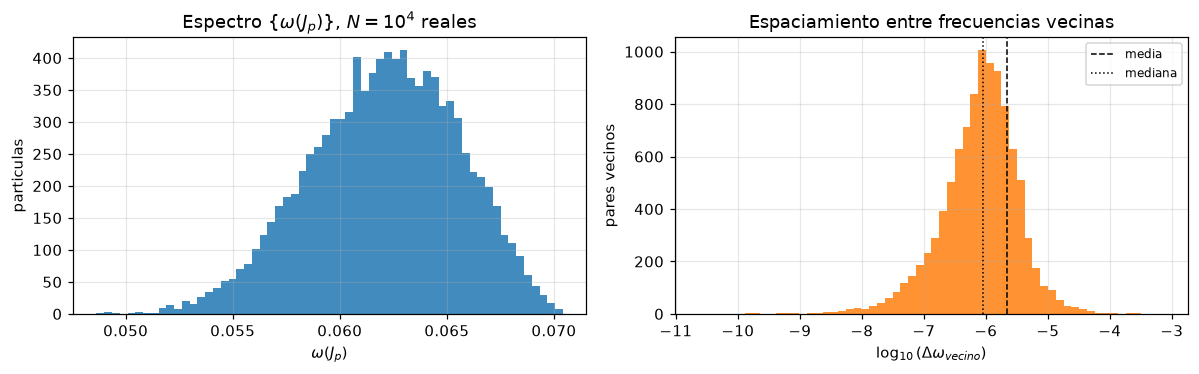

In [29]:

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(om_real, bins=60, color="C0", alpha=0.85)
axes[0].set_xlabel(r"$\omega(J_p)$")
axes[0].set_ylabel("particulas")
axes[0].set_title(r"Espectro $\{\omega(J_p)\}$, $N=10^4$ reales")
axes[0].grid(alpha=0.3)

axes[1].hist(np.log10(gaps), bins=60, color="C1", alpha=0.85)
axes[1].axvline(np.log10(gaps.mean()), color="k", ls="--", lw=1, label="media")
axes[1].axvline(np.log10(np.median(gaps)), color="k", ls=":", lw=1, label="mediana")
axes[1].set_xlabel(r"$\log_{10}(\Delta\omega_{vecino})$")
axes[1].set_ylabel("pares vecinos")
axes[1].set_title("Espaciamiento entre frecuencias vecinas")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig("omega_spectrum.png", dpi=140)
plt.show()



**Resultado**: $T_1\sim1.8\times10^3$ (coincide con que la señal
física ya decayó bastante antes de $t=10^4$, consistente con todo lo
visto) pero $T_2\sim3$-$7\times10^6$ -- **más de 150 veces mayor que
los $t=2\times10^4$ ya simulados**. Esta es la respuesta concreta a la
pregunta abierta de la sección anterior: la curva sigue lisa
simplemente porque **todavía no llegamos ni de cerca** a la escala de
tiempo donde el grano fino de tener "solo" $10^4$ frecuencias
distintas debería notarse. No es que el supuesto de fondo esté mal --
es que $T_2$ es astronómicamente más grande que cualquier tiempo de
simulación razonable para este $N$.

$T_2$ escala aproximadamente con $N$ (más partículas → frecuencias más
apretadas → $T_2$ más grande): una estimación simple
$T_2\sim2\pi N/\sigma_\omega$ da $\sim1.8\times10^7$, del mismo orden
que el espaciamiento medido directamente. Confirma además por qué
aumentar $N_c$ en las secciones anteriores nunca mostró señales de
"grano" -- vamos en la dirección que hace $T_2$ **más grande todavía**,
nunca menor. Llegar a $t\sim T_2$ por fuerza bruta (correr
$\sim100$-$300\times$ más tiempo) no es práctico; si se quisiera
verificar esta predicción directamente, sería más razonable *bajar*
$N$ deliberadamente (para bajar $T_2$ a un rango simulable) y ver si
ahí sí aparece el comportamiento "ruidoso" -- no probado en esta
sesión.
